# 中芯国际 (00981.HK) 技术指标计算

## 四指标研究：RSI / MACD / ATR / 布林带

- **标的**: 中芯国际 (00981.HK)
- **数据时间**: 约 245 个交易日
- **数据来源**: Tushare Pro (港股日线)
- **计算原则**: 从零实现公式，不依赖 ta-lib 等专库

---

## 1. 数据加载与概览

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import warnings
warnings.filterwarnings('ignore')

# ── 中文字体设置 ──
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ── 读取数据 ──
data_path = os.path.join('..', 'smic_hk_daily.csv')
df = pd.read_csv(data_path, encoding='utf-8-sig')
df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
df.sort_values('trade_date', ascending=True, inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"数据行数: {len(df)}")
print(f"日期范围: {df['trade_date'].min().date()} ~ {df['trade_date'].max().date()}")
print(f"字段列表: {list(df.columns)}")
print(f"\n缺失值检查:\\n{df.isnull().sum()}")
print(f"\n描述性统计:")
display(df[['open','high','low','close','vol','amount']].describe().round(2))

数据行数: 245
日期范围: 2025-07-04 ~ 2026-07-03
字段列表: ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 'pre_close', 'change', 'pct_chg', 'vol', 'amount']

缺失值检查:\nts_code       0
trade_date    0
open          0
high          0
low           0
close         0
pre_close     0
change        0
pct_chg       0
vol           0
amount        0
dtype: int64

描述性统计:


,open,high,low,close,vol,amount
count,245.00,245.00,245.00,245.00,2.450000e+02,2.450000e+02
mean,67.40,69.17,65.64,67.27,9.835011e+07,6.782741e+09
std,10.99,11.41,10.42,10.81,5.921792e+07,4.677778e+09
min,43.10,44.80,41.50,43.95,7.346214e+06,5.149122e+08
25%,59.60,60.65,58.30,59.35,5.752537e+07,3.516983e+09
50%,69.60,70.90,68.15,69.40,8.142553e+07,5.389700e+09
75%,75.30,77.15,73.10,75.00,1.201019e+08,8.470709e+09
max,91.80,93.50,88.65,91.05,3.718359e+08,3.257981e+10


## 2. RSI — 相对强弱指标

### 公式原理
$$
RSI = 100 - \frac{100}{1 + RS}, \quad RS = \frac{\text{平均涨幅}}{\text{平均跌幅}}
$$

- **N=14 天**为默认周期
- **取值范围**: 0 ~ 100
- **中线**: 50（多空分界）
- **超买**: RSI > 70
- **超卖**: RSI < 30

In [2]:
def _rsi(close, period=14):
    """
    手动实现 RSI 计算

    参数:
        close  : 收盘价序列 (pd.Series)
        period : 计算周期 (默认 14)

    返回:
        pd.Series, RSI 值序列
    """
    delta = close.diff()
    gain = delta.clip(lower=0)   # 涨幅（负值变 0）
    loss = (-delta).clip(lower=0)  # 跌幅（正值变 0）

    # 使用 Wilder 平滑法（SMMA）：首周期用 SMA，之后递归
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# ── 计算 RSI ──
df['rsi_14'] = _rsi(df['close'], 14)

# 展示近期结果
print("最近 5 日 RSI 值:")
display(df[['trade_date', 'close', 'rsi_14']].tail(5).round(2))

# 最新 RSI
latest_rsi = df['rsi_14'].iloc[-1]
print(f"\\n最新 RSI = {latest_rsi:.2f}")
if latest_rsi > 70:
    print(f"  → RSI > 70，处于超买区，短期可能回调")
elif latest_rsi < 30:
    print(f"  → RSI < 30，处于超卖区，短期可能反弹")
else:
    print(f"  → RSI 处于中性区 (30~70)，趋势正常延续")

最近 5 日 RSI 值:


,trade_date,close,rsi_14
240,2026-06-26,80.0,53.95
241,2026-06-29,84.8,59.23
242,2026-06-30,89.4,63.54
243,2026-07-02,80.4,51.96
244,2026-07-03,77.6,48.97


\n最新 RSI = 48.97
  → RSI 处于中性区 (30~70)，趋势正常延续


findfont: Failed to find font weight bold, now using 400.


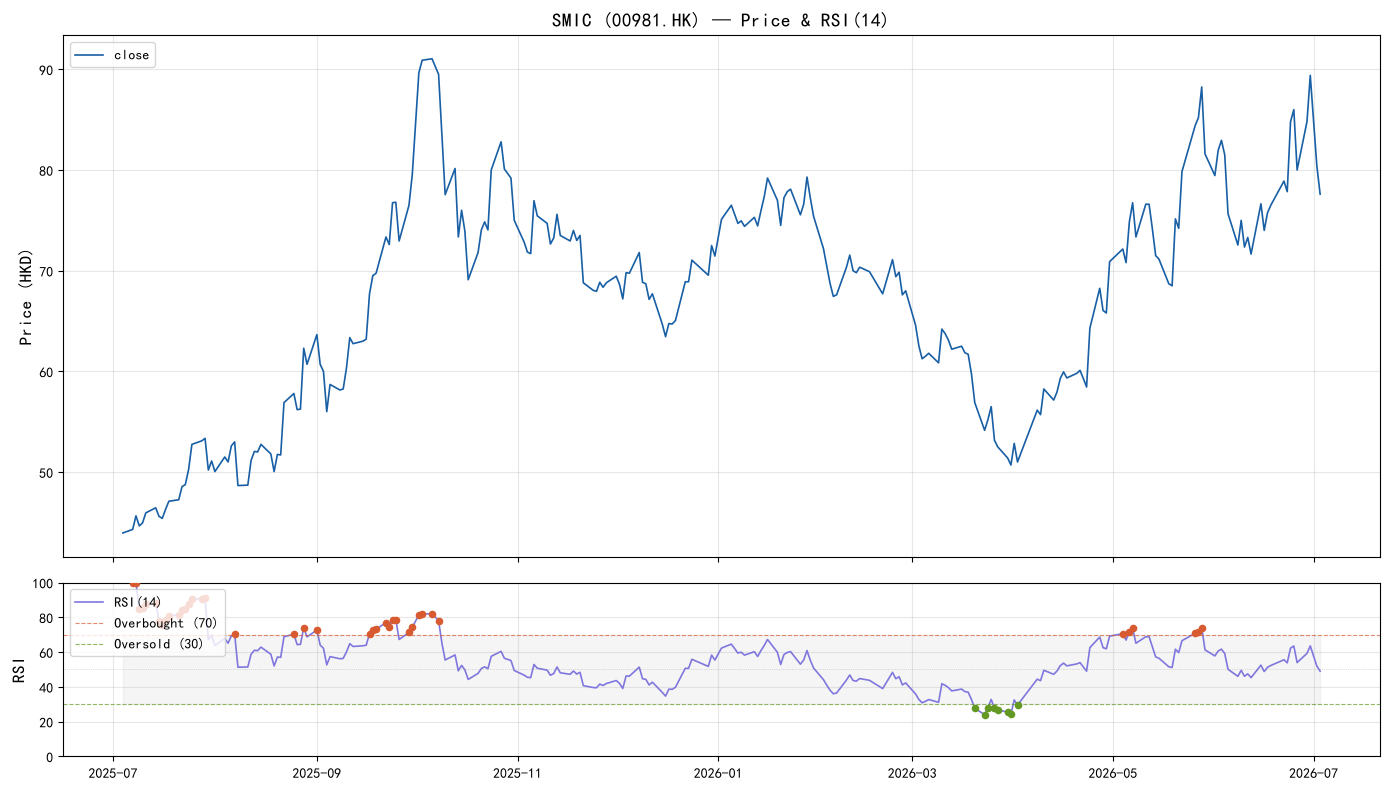

超买区域出现: 40 次
超卖区域出现: 8 次


In [3]:
# ── RSI 可视化 ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# 上：价格走势
ax1.plot(df['trade_date'], df['close'], label='close', color='#185FA5', linewidth=1.2)
ax1.set_ylabel('Price (HKD)', fontsize=12)
ax1.set_title('SMIC (00981.HK) — Price & RSI(14)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 下：RSI
ax2.plot(df['trade_date'], df['rsi_14'], label='RSI(14)', color='#7F77DD', linewidth=1.2)
ax2.axhline(y=70, color='#D85A30', linestyle='--', alpha=0.7, linewidth=0.8, label='Overbought (70)')
ax2.axhline(y=30, color='#639922', linestyle='--', alpha=0.7, linewidth=0.8, label='Oversold (30)')
ax2.axhline(y=50, color='gray', linestyle=':', alpha=0.5, linewidth=0.5)
ax2.fill_between(df['trade_date'], 30, 70, alpha=0.08, color='gray')
ax2.set_ylabel('RSI', fontsize=12)
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# 标记超买超卖
overbought = df[df['rsi_14'] > 70]
oversold = df[df['rsi_14'] < 30]
ax2.scatter(overbought['trade_date'], overbought['rsi_14'], color='#D85A30', s=20, zorder=5, label='Overbought')
ax2.scatter(oversold['trade_date'], oversold['rsi_14'], color='#639922', s=20, zorder=5, label='Oversold')

plt.tight_layout()
plt.show()

print(f"超买区域出现: {len(overbought)} 次")
print(f"超卖区域出现: {len(oversold)} 次")

### RSI 关键发现
- RSI 超过 70 并不一定立即下跌——**强趋势行情中 RSI 可以长时间维持在超买区**
- 最可靠的信号是 **背离 (divergence)**：价格创新高但 RSI 未创新高
- 结合超买/超卖 + K 线形态（如 pin bar、吞没）效果更好

## 3. MACD — 异同移动平均线

### 公式原理
$$
\begin{aligned}
\text{DIF} &= EMA(close, 12) - EMA(close, 26) \\
\text{DEA} &= EMA(DIF, 9) \\
\text{MACD柱} &= 2 \times (DIF - DEA)
\end{aligned}
$$

- **DIF 快线**: 短期与长期 EMA 的差值，反映趋势动量
- **DEA 慢线**: DIF 的平滑线，过滤噪音
- **MACD 柱**: 快慢线差距的可视化"气柱"
- **零轴**: DIF 的正负分界，零上多头、零下空头

In [4]:
def _ema(series, period):
    """指数移动平均 (EWM)"""
    return series.ewm(span=period, adjust=False).mean()

def _macd(close, fast=12, slow=26, signal=9):
    """
    手动实现 MACD 计算

    返回:
        (dif, dea, hist) 三元组
    """
    dif = _ema(close, fast) - _ema(close, slow)
    dea = _ema(dif, signal)
    hist = 2 * (dif - dea)
    return dif, dea, hist

# ── 计算 MACD ──
df['macd_dif'], df['macd_dea'], df['macd_hist'] = _macd(df['close'])

print("最近 5 日 MACD 值:")
display(df[['trade_date', 'close', 'macd_dif', 'macd_dea', 'macd_hist']].tail(5).round(4))

# 最新信号
last = df.iloc[-1]
print(f"\\n最新信号:")
print(f"  DIF = {last['macd_dif']:.4f}  DEA = {last['macd_dea']:.4f}")
if last['macd_dif'] > last['macd_dea']:
    print(f"  → DIF > DEA，多头主导，DIF 线向上")
else:
    print(f"  → DIF < DEA，空头主导，DIF 线向下")
if last['macd_dif'] > 0:
    print(f"  → DIF > 0，处于零轴上方，多头市场")
else:
    print(f"  → DIF < 0，处于零轴下方，空头市场")

最近 5 日 MACD 值:


,trade_date,close,macd_dif,macd_dea,macd_hist
240,2026-06-26,80.0,1.9609,1.5146,0.8928
241,2026-06-29,84.8,2.2645,1.6646,1.1999
242,2026-06-30,89.4,2.8435,1.9004,1.8863
243,2026-07-02,80.4,2.5468,2.0296,1.0343
244,2026-07-03,77.6,2.0619,2.0361,0.0517


\n最新信号:
  DIF = 2.0619  DEA = 2.0361
  → DIF > DEA，多头主导，DIF 线向上
  → DIF > 0，处于零轴上方，多头市场


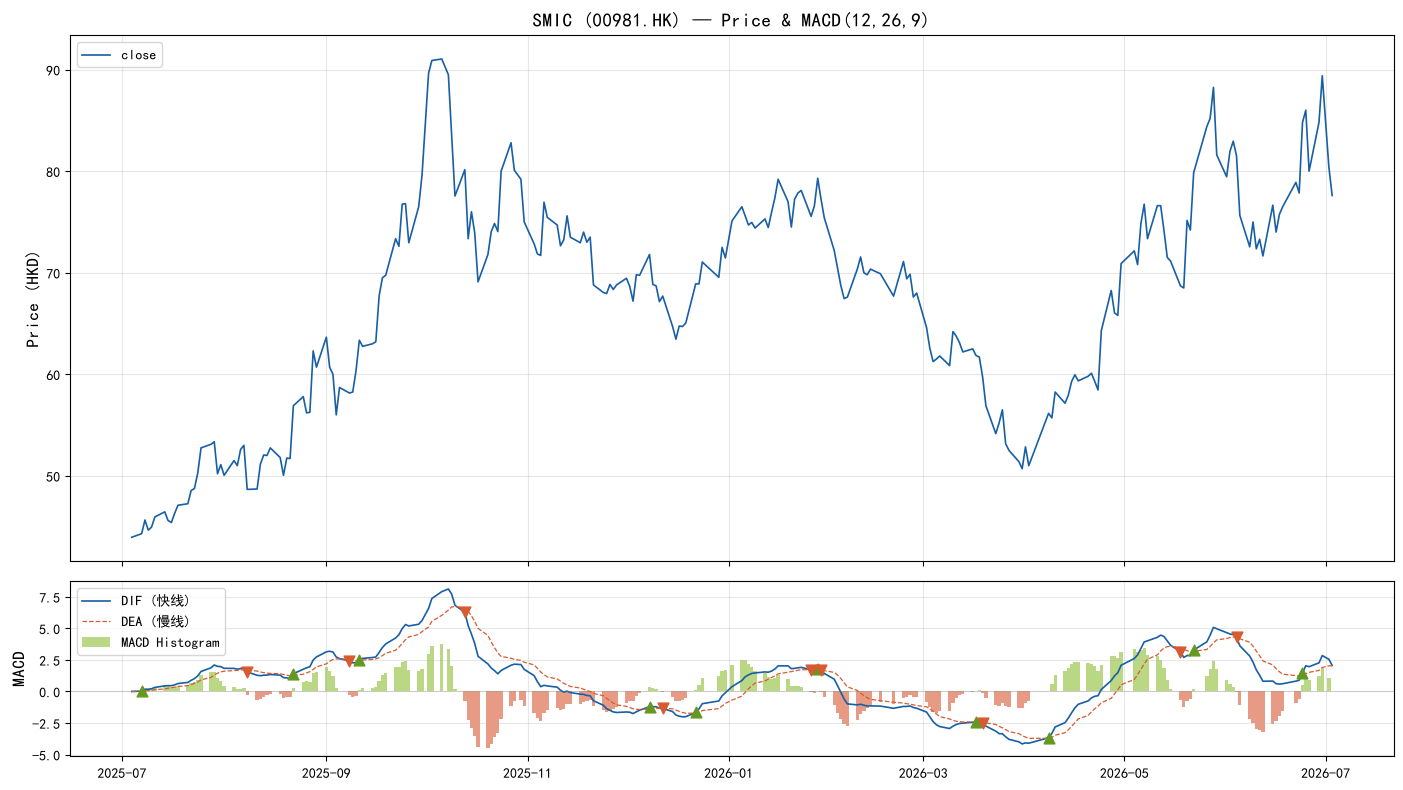

金叉次数: 10    死叉次数: 9


In [5]:
# ── MACD 可视化 ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# 上：价格
ax1.plot(df['trade_date'], df['close'], label='close', color='#185FA5', linewidth=1.2)
ax1.set_ylabel('Price (HKD)', fontsize=12)
ax1.set_title('SMIC (00981.HK) — Price & MACD(12,26,9)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 下：MACD
ax2.plot(df['trade_date'], df['macd_dif'], label='DIF (快线)', color='#185FA5', linewidth=1.2)
ax2.plot(df['trade_date'], df['macd_dea'], label='DEA (慢线)', color='#D85A30', linewidth=0.9, linestyle='--')
ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.4, linewidth=0.5)
ax2.bar(df['trade_date'], df['macd_hist'], width=1,
        color=[(0.55, 0.75, 0.20) if v >= 0 else (0.85, 0.35, 0.20) for v in df['macd_hist']],
        alpha=0.6, label='MACD Histogram')
ax2.set_ylabel('MACD', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# 标记金叉死叉
golden = (df['macd_dif'] > df['macd_dea']) & (df['macd_dif'].shift(1) <= df['macd_dea'].shift(1))
death  = (df['macd_dif'] < df['macd_dea']) & (df['macd_dif'].shift(1) >= df['macd_dea'].shift(1))
ax2.scatter(df.loc[golden, 'trade_date'], df.loc[golden, 'macd_dif'],
            marker='^', color='#639922', s=60, zorder=5, label='Golden Cross')
ax2.scatter(df.loc[death, 'trade_date'], df.loc[death, 'macd_dif'],
            marker='v', color='#D85A30', s=60, zorder=5, label='Death Cross')

plt.tight_layout()
plt.show()

print(f"金叉次数: {golden.sum()}    死叉次数: {death.sum()}")

### MACD 关键发现
- **金叉/死叉在零轴附近最可靠**——远离零轴时可能是趋势末端信号
- **柱体由长变短**: 动能在衰减，即使 DIF 仍在正向运行
- **适用于趋势行情**，横盘震荡时频繁金叉死叉反成噪音

## 4. ATR — 平均真实波幅

### 公式原理
$$
\begin{aligned}
TR &= \max(H - L,\, |H - PC|,\, |L - PC|) \\
ATR &= SMA(TR, 14)
\end{aligned}
$$

- **TR (True Range)**: 取三种波幅计算的最大值，避免跳空缺口不被计入
- **ATR** = TR 的 14 天移动平均
- **不预测方向，只衡量波幅**
- **主要用途**: 设定止损、仓位管理、波动率过滤器

In [6]:
def _atr(high, low, close, period=14):
    """
    手动实现 ATR 计算

    参数:
        high   : 最高价序列
        low    : 最低价序列
        close  : 收盘价序列
        period : 计算周期 (默认 14)

    返回:
        pd.Series, ATR 值序列
    """
    prev_close = close.shift(1)

    tr1 = high - low              # 今日振幅
    tr2 = (high - prev_close).abs()   # 向上跳空
    tr3 = (low - prev_close).abs()    # 向下跳空

    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

    # Wilder 平滑
    atr = tr.ewm(alpha=1/period, adjust=False).mean()
    return atr

def _tr(high, low, close):
    """返回 TR 序列（辅助分析）"""
    prev_close = close.shift(1)
    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()
    return pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

# ── 计算 ATR ──
df['tr'] = _tr(df['high'], df['low'], df['close'])
df['atr_14'] = _atr(df['high'], df['low'], df['close'], 14)

print("最近 5 日 TR 和 ATR:")
display(df[['trade_date', 'high', 'low', 'close', 'tr', 'atr_14']].tail(5).round(4))

# ATR 实用计算
latest_price = df['close'].iloc[-1]
latest_atr = df['atr_14'].iloc[-1]
print(f"\\n最新收盘价: {latest_price:.2f}")
print(f"最新 ATR(14): {latest_atr:.4f}")
print(f"ATR / 价格比例: {latest_atr / latest_price * 100:.2f}%")
print(f"\\n基于 ATR 的止损参考:")
print(f"  1倍 ATR 止损: {latest_price - latest_atr:.2f}")
print(f"  2倍 ATR 止损: {latest_price - 2 * latest_atr:.2f}")
print(f"  3倍 ATR 止损: {latest_price - 3 * latest_atr:.2f}")

最近 5 日 TR 和 ATR:


,trade_date,high,low,close,tr,atr_14
240,2026-06-26,85.25,79.05,80.0,6.95,5.8027
241,2026-06-29,85.80,79.35,84.8,6.45,5.8489
242,2026-06-30,91.55,84.25,89.4,7.30,5.9526
243,2026-07-02,84.20,78.55,80.4,10.85,6.3024
244,2026-07-03,81.45,76.45,77.6,5.00,6.2094


\n最新收盘价: 77.60
最新 ATR(14): 6.2094
ATR / 价格比例: 8.00%
\n基于 ATR 的止损参考:
  1倍 ATR 止损: 71.39
  2倍 ATR 止损: 65.18
  3倍 ATR 止损: 58.97


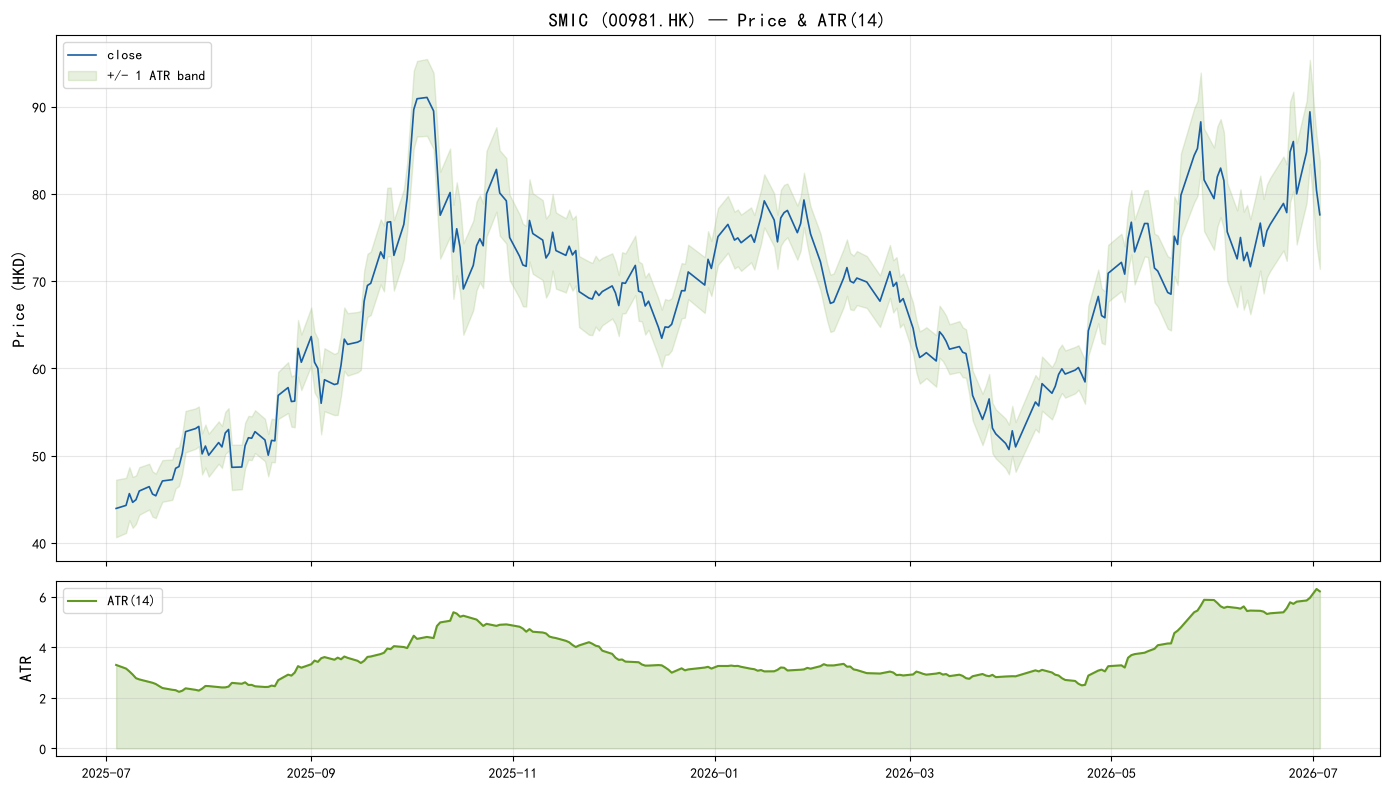

ATR 均值: 3.6355
高波动期 (ATR > 均值×1.5): 18 天
高波动日期范围: 2026-05-28 ~ 2026-07-03


In [7]:
# ── ATR 可视化 ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# 上：价格
ax1.plot(df['trade_date'], df['close'], label='close', color='#185FA5', linewidth=1.2)
ax1.fill_between(df['trade_date'],
                 df['close'] - df['atr_14'],
                 df['close'] + df['atr_14'],
                 alpha=0.15, color='#639922', label='+/- 1 ATR band')
ax1.set_ylabel('Price (HKD)', fontsize=12)
ax1.set_title('SMIC (00981.HK) — Price & ATR(14)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 下：ATR
ax2.plot(df['trade_date'], df['atr_14'], label='ATR(14)', color='#639922', linewidth=1.5)
ax2.fill_between(df['trade_date'], 0, df['atr_14'], alpha=0.2, color='#639922')
ax2.set_ylabel('ATR', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 识别高波动期
avg_atr = df['atr_14'].mean()
high_vol = df[df['atr_14'] > avg_atr * 1.5]
print(f"ATR 均值: {avg_atr:.4f}")
print(f"高波动期 (ATR > 均值×1.5): {len(high_vol)} 天")
if len(high_vol) > 0:
    print(f"高波动日期范围: {high_vol['trade_date'].iloc[0].date()} ~ {high_vol['trade_date'].iloc[-1].date()}")

### ATR 关键发现
- ATR 上升 → 市场波动加剧，通常伴随重要消息或突破
- ATR 下降 → 市场横盘整理，处于积累期
- **布林带挤压 + ATR 低位**：变盘前兆的强力信号组合
- ATR 最大的价值不在交易信号本身，而在 **风险控制**

## 5. 布林带 — Bollinger Bands

### 公式原理
$$
\begin{aligned}
\text{中轨} &= SMA(close, 20) \\
\text{标准差}~\sigma &= std(close, 20) \\
\text{上轨} &= \text{中轨} + 2 \times \sigma \\
\text{下轨} &= \text{中轨} - 2 \times \sigma \\
\%B &= \frac{close - \text{下轨}}{\text{上轨} - \text{下轨}}
\end{aligned}
$$

- **%B**: 价格在布林带内的相对位置，0-1 之间表示在下轨到上轨之间
- **带宽**: 上轨 - 下轨，表示当前波动率水平

In [8]:
def _bollinger(close, period=20, std_dev=2):
    """
    手动实现布林带计算

    参数:
        close   : 收盘价序列
        period  : 移动平均周期 (默认 20)
        std_dev : 标准差倍数 (默认 2)

    返回:
        (middle, upper, lower, bandwidth, percent_b) 五元组
    """
    middle = close.rolling(window=period).mean()
    std = close.rolling(window=period).std(ddof=0)  # 总体标准差

    upper = middle + std_dev * std
    lower = middle - std_dev * std
    bandwidth = upper - lower
    percent_b = (close - lower) / bandwidth
    return middle, upper, lower, bandwidth, percent_b

# ── 计算布林带 ──
df['bb_middle'], df['bb_upper'], df['bb_lower'], df['bb_width'], df['bb_pct_b'] = \
    _bollinger(df['close'], 20, 2)

print("最近 5 日布林带:")
display(df[['trade_date', 'close', 'bb_upper', 'bb_middle', 'bb_lower', 'bb_width', 'bb_pct_b']].tail(5).round(4))

latest = df.iloc[-1]
print(f"\\n最新值:")
print(f"  收盘价: {latest['close']:.2f}")
print(f"  上轨:   {latest['bb_upper']:.2f}")
print(f"  中轨:   {latest['bb_middle']:.2f}")
print(f"  下轨:   {latest['bb_lower']:.2f}")
print(f"  %B:     {latest['bb_pct_b']:.2%}")
if latest['close'] > latest['bb_upper']:
    print(f"  → 价格突破上轨! 超买区，注意回调风险")
elif latest['close'] < latest['bb_lower']:
    print(f"  → 价格低于下轨! 超卖区，关注反弹机会")
else:
    print(f"  → 价格在通道内正常波动")

最近 5 日布林带:


,trade_date,close,bb_upper,bb_middle,bb_lower,bb_width,bb_pct_b
240,2026-06-26,80.0,86.2393,77.9200,69.6007,16.6387,0.6250
241,2026-06-29,84.8,86.7902,78.0800,69.3698,17.4204,0.8858
242,2026-06-30,89.4,88.5840,78.5775,68.5710,20.0130,1.0408
243,2026-07-02,80.4,88.4245,78.5000,68.5755,19.8490,0.5957
244,2026-07-03,77.6,87.9490,78.2325,68.5160,19.4331,0.4675


\n最新值:
  收盘价: 77.60
  上轨:   87.95
  中轨:   78.23
  下轨:   68.52
  %B:     46.75%
  → 价格在通道内正常波动


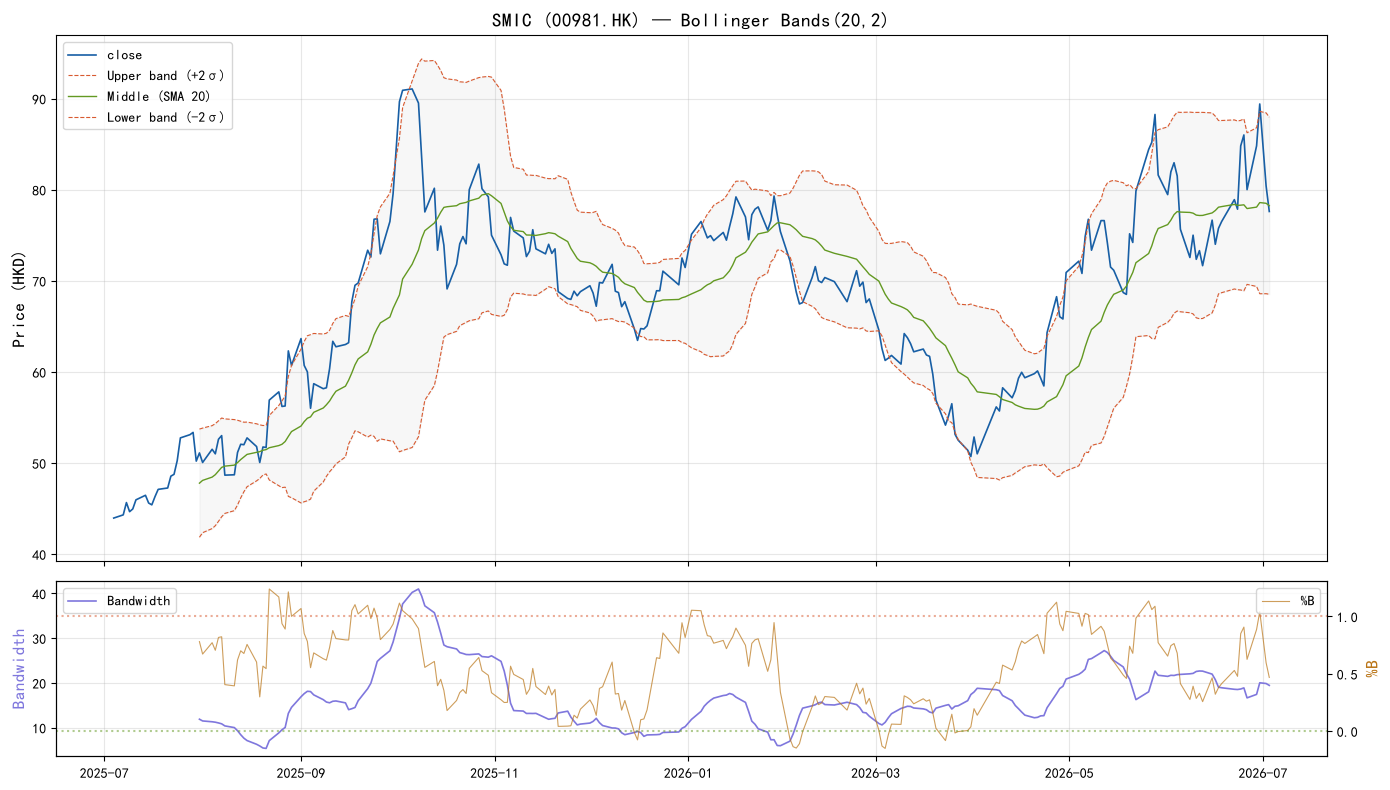

In [9]:
# ── 布林带可视化 ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# 上：布林带 + 价格
ax1.plot(df['trade_date'], df['close'], label='close', color='#185FA5', linewidth=1.2)
ax1.plot(df['trade_date'], df['bb_upper'], label='Upper band (+2σ)', color='#D85A30', linewidth=0.8, linestyle='--')
ax1.plot(df['trade_date'], df['bb_middle'], label='Middle (SMA 20)', color='#639922', linewidth=1.0)
ax1.plot(df['trade_date'], df['bb_lower'], label='Lower band (-2σ)', color='#D85A30', linewidth=0.8, linestyle='--')
ax1.fill_between(df['trade_date'], df['bb_upper'], df['bb_lower'], alpha=0.06, color='gray')
ax1.set_ylabel('Price (HKD)', fontsize=12)
ax1.set_title('SMIC (00981.HK) — Bollinger Bands(20,2)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 下：带宽 + %B
ax2.plot(df['trade_date'], df['bb_width'], label='Bandwidth', color='#7F77DD', linewidth=1.2)
ax2.set_ylabel('Bandwidth', fontsize=12, color='#7F77DD')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

ax_twin = ax2.twinx()
ax_twin.plot(df['trade_date'], df['bb_pct_b'], label='%B', color='#BA7517', linewidth=0.8, alpha=0.7)
ax_twin.axhline(y=1.0, color='#D85A30', linestyle=':', alpha=0.5)
ax_twin.axhline(y=0.0, color='#639922', linestyle=':', alpha=0.5)
ax_twin.set_ylabel('%B', fontsize=12, color='#BA7517')
ax_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

### 布林带关键发现
- **带宽收缩 (squeeze)** 是最值得关注的信号——波动率压缩到极致后通常会爆发
- **价格突破上轨** 不代表要立即做空——强趋势中价格可沿上轨上行
- **%B 超过 1.0 或低于 0** 是极端行情信号
- 布林带 + RSI 配合使用效果最佳：触轨 + RSI 背离 = 强反转信号

## 6. 总结对照

| 指标 | 告诉我们什么 | 何时最有效 | 何时失效 |
|------|-------------|-----------|---------|
| **RSI** | 涨跌的强弱力度，是否过度 | 震荡市、短线反转 | 强趋势（长期钝化） |
| **MACD** | 趋势的方向和动能变化 | 趋势行情、波段 | 横盘震荡（假信号） |
| **ATR** | 波动的剧烈程度，不判断方向 | 任何时候 — 纯风控 | — |
| **布林带** | 价格在统计上的相对位置 | 震荡市均值回归 | 单边强趋势 |

### 实战组合示例

```
入场条件（做多）:
  1. 布林带 squeeze 后价格向上突破中轨
  2. MACD 金叉或 DIF 拐头向上
  3. RSI > 50 且未超买 (< 70)
  4. ATR 确认波动在合理范围
  
止损:
  止损价 = 入场价 - 2 × ATR(14)
  
仓位:
  仓位 = 总资金 × 1% / (2 × ATR)
```

### 思考
- **没有万能指标**: 每种指标都有其适用场景和限制
- **指标组合 > 单一指标**: 至少从两种互补类别中各取一个（如 RSI + 布林带）
- **尊重数据**: 指标是工具，而不是圣杯。最终决定来自对市场的理解

In [10]:
print("=" * 55)
print("  全部指标计算完成!")
print("=" * 55)
print()
print("输出文件:")
print(f"  smic_hk_daily.csv             — 原始数据（{len(df)} 行）")
print(f"  indicator_lab.ipynb                — 本 Notebook")
print(f"  spec.md                            — 项目规范")
print()
print(f"新增指标列: {[c for c in df.columns if c not in ['ts_code','trade_date','open','high','low','close','pre_close','change','pct_chg','vol','amount']]}")

  全部指标计算完成!

输出文件:
  smic_hk_daily.csv             — 原始数据（245 行）
  indicator_lab.ipynb                — 本 Notebook
  spec.md                            — 项目规范

新增指标列: ['rsi_14', 'macd_dif', 'macd_dea', 'macd_hist', 'tr', 'atr_14', 'bb_middle', 'bb_upper', 'bb_lower', 'bb_width', 'bb_pct_b']
